In [2]:
import pandas as pd
import mysql.connector

In [15]:
import mysql.connector

conn.close()

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="sql_cx"
)

In [18]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable.*"
)

In [35]:
df = pd.read_sql_query("""
SELECT
CONCAT('Match-', CAST(ROW_NUMBER() OVER (ORDER BY ID) AS CHAR)) AS match_no,
SUM(batsman_run) AS runs_scored,
SUM(SUM(batsman_run)) OVER w AS career_runs,
ROUND(AVG(SUM(batsman_run)) OVER w, 2) AS career_runs_avg,
ROUND(AVG(SUM(batsman_run)) OVER(ROWS BETWEEN 9 PRECEDING AND CURRENT ROW), 2) AS rolling_avg
FROM ipl
WHERE batter = 'V kohli'
GROUP BY ID
WINDOW w AS (
ORDER BY ID
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
)
""", conn)

In [36]:
import matplotlib.pyplot as plt

In [37]:
df.head()

,match_no,runs_scored,career_runs,career_runs_avg,rolling_avg
0,Match-1,1.0,1.0,1.00,1.00
1,Match-2,23.0,24.0,12.00,12.00
2,Match-3,13.0,37.0,12.33,12.33
3,Match-4,12.0,49.0,12.25,12.25
4,Match-5,1.0,50.0,10.00,10.00


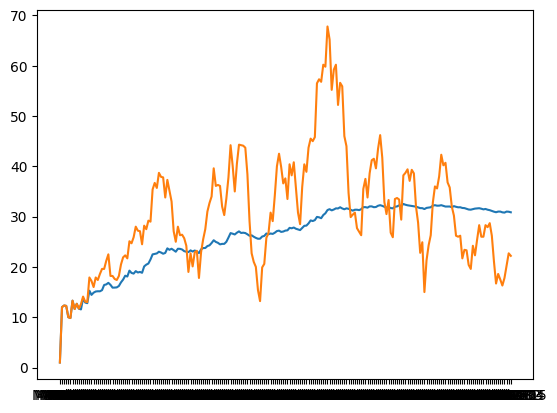

In [38]:
plt.plot(df['match_no'], df['career_runs_avg'])
plt.plot(df['match_no'], df['rolling_avg'])